# Cubic splines



Splines were formulated to relieve oscillations attributed to Runge's phenomenon by piecing together a series of lower-order polynomials and requiring *smoothness*. Consider a polynomial over the interval between $x_i$ and $x_{i+1}$, and assert:
* $y(x_i) = y_i$
* $y(x_{i+1}) = y_{i+1}$
* $y'(x_i)$ be continuous
* $y''(x_i)$ be continuous

with these 4 constraints, it is clear we are looking for cubic functions, and therefore these splines are *piecewise cubic curves*.

We will be describing the splines in terms of the *knots*, $k_i$ which parameterize the curves. For these splines, these knots are the second derivatives at a point $x_i$.

To find the coefficients of the cubic splines, consider that the second derivative is linear and represent it with a 2-point Lagrange interpolation:
\begin{align}
y''_{i, i+1} &= k_i P_i(x) + k_{i+1} P_{i+1}(x) \\
&= \frac{k_i [x-x_{i+1}] + k_{i+1} [x-x_i]}{x_i-x_{i+1}}
\end{align}

Using the constraints above we end up with:

$$k_{i-1}[x_{i-1}-x_i]  + 2 k_i [x_{i-1} - x_{i+1}] + k_{i+1}[x_i-x_{i+1}] = 6\left[ \frac{y_{i-1}-y_i}{x_{i-1}-x_i} - \frac{y_{i}-y_{i+1}}{x_{i}-x_{i+1}} \right]$$

which is a tridiagonal matrix!

$$ \begin{bmatrix}
1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
1 & 4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 1 & 4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 4 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 4 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 4 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 4 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 4 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 4 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 4 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
\begin{bmatrix}
k_1 \\
k_2\\
k_3\\
k_4\\
k_5\\
k_6\\
k_7\\
k_8\\
k_9\\
k_{10}\\
k_{11}
\end{bmatrix}
=
\begin{bmatrix}
0\\
-0.424 \\
-1.052 \\
-0.891 \\
1.138 \\
2.654 \\
1.138 \\
-0.891 \\
-1.052 \\
-0.424 \\
0
\end{bmatrix}
$$


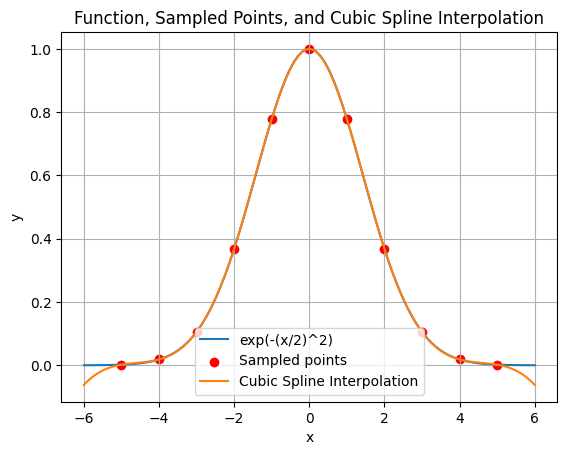

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline

# Define the function
def f(x):
  return np.exp(-(x/2)**2)

# Create x values for plotting
x_toy = np.linspace(-6, 6, 100)
y_toy = f(x_toy)

# Sample 11 times at 1-interval intervals
x_d = np.arange(-5, 6, 1)
y_d = f(x_d)

# Create a cubic spline interpolation
cs = CubicSpline(x_d, y_d)

# Create x values for plotting the interpolated spline
x_interp = np.linspace(-6, 6, 200)
y_interp = cs(x_interp)

# Plot the original curve, sampled points, and interpolated spline
plt.plot(x_toy, y_toy, label='exp(-(x/2)^2)')
plt.scatter(x_d, y_d, color='red', label='Sampled points')
plt.plot(x_interp, y_interp, label='Cubic Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Function, Sampled Points, and Cubic Spline Interpolation')
plt.grid(True)
plt.show()


## Analysis of cubic splines


We note:
* Cubic splines are *stiffer* in that they don't have high-frequency oscillations (thus avoiding Runge's phenomenon).
* The concept of *smoothness* is easy in 1D, but what does it mean for 2D+? How would you ensure continuity along an edge?
* Specifying *smoothness* as part of the goals going in suggest this is more of a global scheme. This requires simultaneous linears systems to be solved.